In [16]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

In [18]:
model_kmeans.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'random',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 'auto',
 'random_state': 42,
 'tol': 0.0001,
 'verbose': 0}

In [19]:
import warnings
warnings.filterwarnings("ignore")

In [20]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [21]:
model_kmeans = KMeans(
    n_clusters=3,
    init = 'random',
    random_state=42
)

model_kmeans


KMeans(init='random', n_clusters=3, random_state=42)

In [22]:
df['KClustering'] = model_kmeans.fit_predict(df)

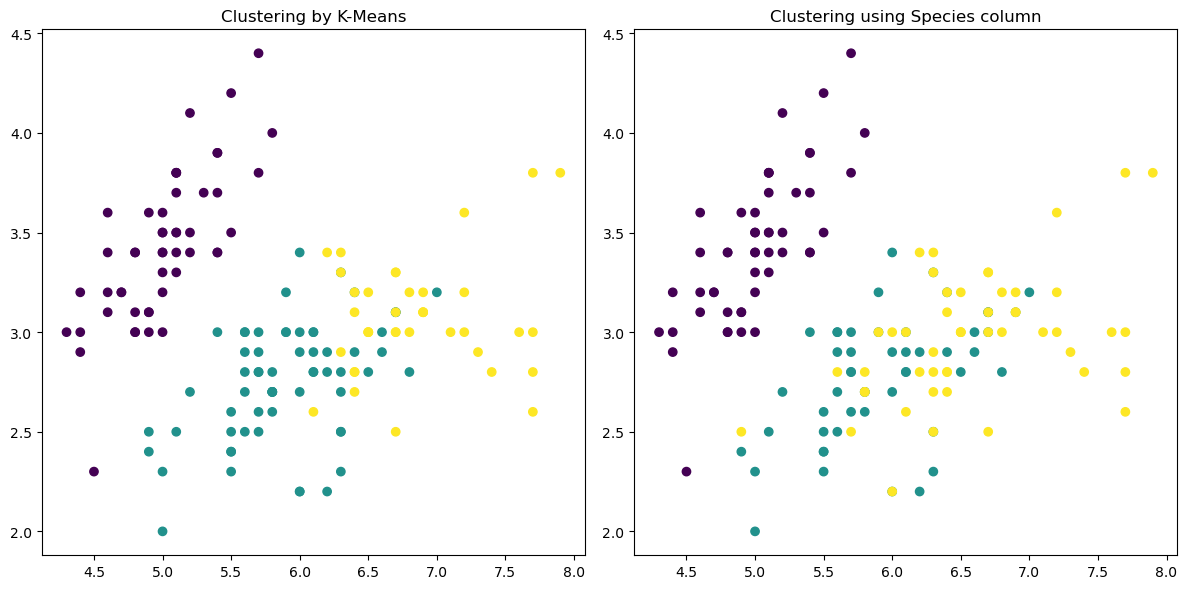

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# KMeans clustering result
ax[0].scatter(
    df['sepal length (cm)'],
    df['sepal width (cm)'],
    c=df['KClustering']
)
ax[0].set_title('Clustering by K-Means')

# Actual species labels
ax[1].scatter(
    df['sepal length (cm)'],
    df['sepal width (cm)'],
    c=data.target
)
ax[1].set_title('Clustering using Species column')

plt.tight_layout()
plt.show()

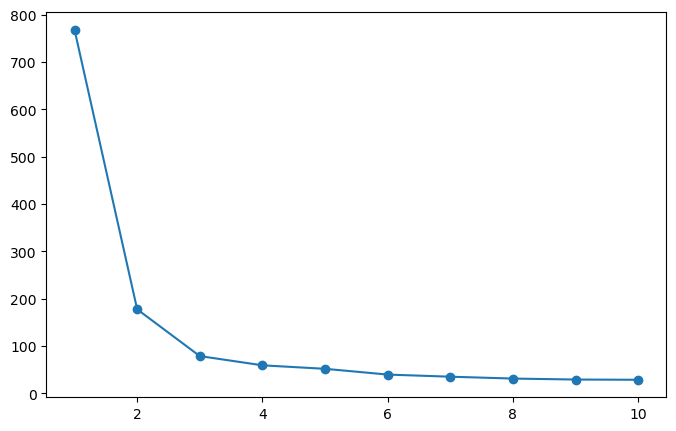

In [27]:
# Elbow method

errors = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='random', random_state=42)
    kmeans.fit(df)
    errors.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), errors, marker='o')  


## Customer Segmentation Project

- Mall Customers dataset 
- we will implement K means clustering to check the spending patterns of our customers
- segment the customer spending behaviour

Task:
1. data ingestion/acquisition
2. Data EDA
3. Preprocessing, if needed
4. train a model 
5. Cluster the users 

Optional
6. Tag each cluter with a name and save that column in dataframe

In [ ]:
# 1. Data Ingestion / Acquisition

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [30]:
# 2. Data EDA (Exploratory Data Analysis)
# Basic understanding

df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


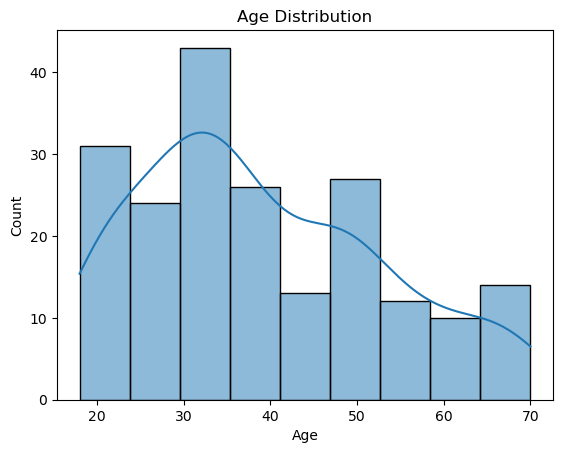

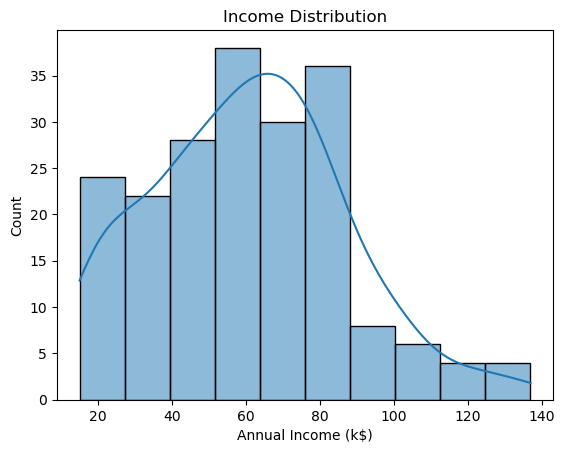

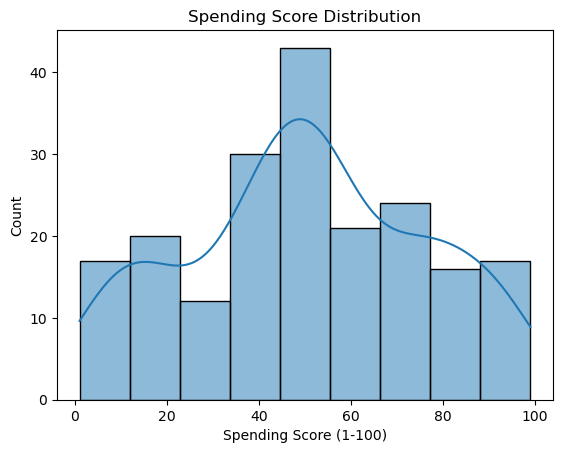

In [31]:
# 2. Data EDA (Exploratory Data Analysis)
# Check distribution of key features

import seaborn as sns

sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title("Income Distribution")
plt.show()

sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title("Spending Score Distribution")
plt.show()

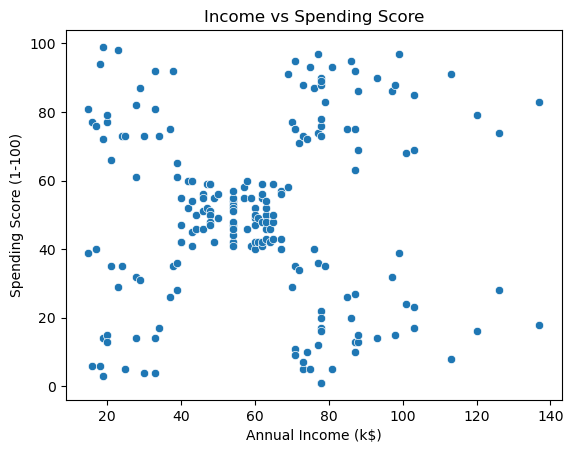

In [32]:
# 2. Data EDA (Exploratory Data Analysis)
# Relationship (VERY important for clustering insight)

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

In [33]:
# 3. Preprocessing (Important for K-Means)
# Step 1: Select features

# We focus on spending behavior:

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [42]:
# 3. Preprocessing (Important for K-Means)
# Step 2: Feature scaling (VERY IMPORTANT)

# K-Means depends on distance → scaling is required

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# print(X_scaled)

In [35]:
# 4. Train Model (Find best K)

# Elbow Method

errors = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    errors.append(kmeans.inertia_)

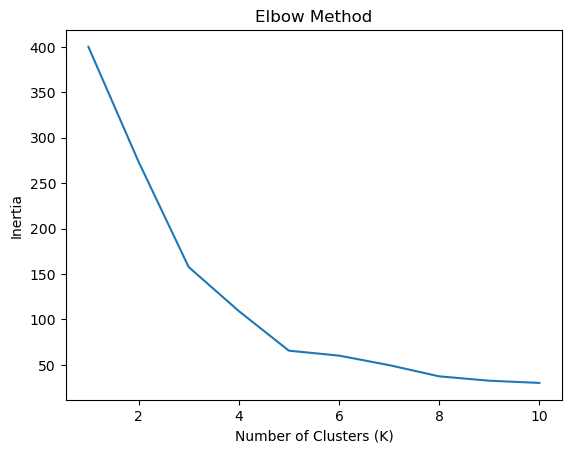

In [36]:
# 4. Train Model (Find best K)

# Plot elbow curve


plt.plot(range(1, 11), errors)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
# Choose K

# Usually for this dataset:

# K = 4 or 5 is optimal (based on elbow bend)

In [37]:
# 5. Cluster Users (Final Model)

# Assume K = 5

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


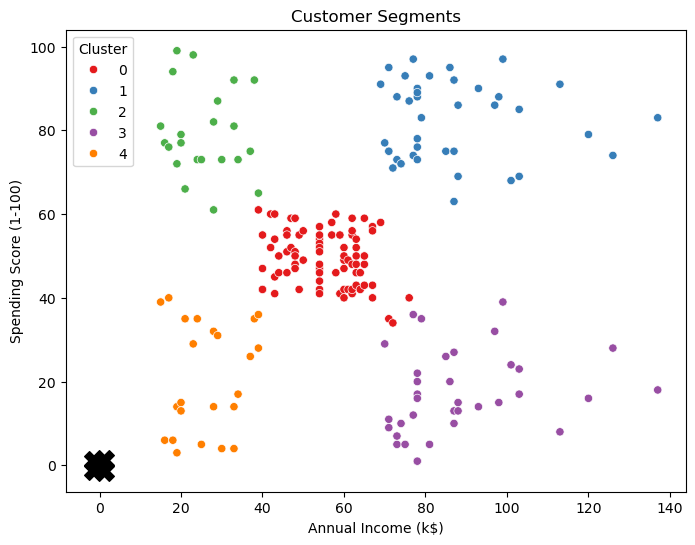

In [38]:
# Visualize clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    c='black',
    marker='X'
)

plt.title("Customer Segments")
plt.show()

6. Optional: Tag Clusters (Business Meaning)

Now interpret clusters:

Example interpretation:

Cluster	Meaning
0	Low income, low spending
1	High income, high spending
2	High income, low spending
3	Low income, high spending
4	Average customers

In [ ]:
# Add labels

cluster_names = {
    0: "Low Value Customers",
    1: "Premium Customers",
    2: "Careful Spenders",
    3: "Impulse Buyers",
    4: "Average Customers"
}

df['Segment'] = df['Cluster'].map(cluster_names)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,4,Average Customers
1,2,Male,21,15,81,2,Careful Spenders
2,3,Female,20,16,6,4,Average Customers
3,4,Female,23,16,77,2,Careful Spenders
4,5,Female,31,17,40,4,Average Customers


In [40]:
# Save final dataset

df.to_csv("customer_segmentation_result.csv", index=False)

## EXPLANATION

🛍️ Customer Segmentation with K-Means (Full Process)

You are trying to:

Group customers based on similar spending behavior so the business can target them better.

1️⃣ Data Ingestion (Get the data)
df = pd.read_csv(url)
What happens here?
You load customer data into a table (DataFrame)
Each row = 1 customer
Each column = customer information
2️⃣ Data Understanding (EDA)

You explore:

df.info()
df.describe()
What you learn:
How many customers
Income range
Spending score range
Age distribution
Example insight:
Some customers earn a lot but spend little
Some earn less but spend a lot

👉 This is the reason clustering is useful

3️⃣ Feature Selection (Choose important data)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
Why only these 2?

Because:

We want to segment based on spending behavior
These two features show customer value clearly
4️⃣ Data Preprocessing (Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
What happens here?

K-Means uses distance (Euclidean distance).

Problem:

Income is large numbers (0–100k)
Spending score is small (1–100)

👉 Income would dominate clustering ❌

After scaling:
All features become equal importance
Mean = 0
Std = 1

✔ Now clustering becomes fair

5️⃣ Choosing number of clusters (K)
Elbow Method:
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    errors.append(kmeans.inertia_)
What is inertia?

How far points are from their cluster center

High inertia = bad clustering
Low inertia = better clustering
Plot:

You look for the “bend” in graph:
👉 That is the best K

Usually:

K = 4 or 5 for this dataset
6️⃣ Train Final K-Means Model
kmeans = KMeans(n_clusters=5, init='k-means++')
df['Cluster'] = kmeans.fit_predict(X_scaled)
What happens internally?

K-Means repeats 3 steps:

🔁 Step A: Assign points

Each customer → closest centroid

🔁 Step B: Update centroids

Move center of each cluster

🔁 Step C: Repeat

Until stable (no big changes)

7️⃣ Cluster Output (Result)

Now each customer has a label:

Customer	Income	Spending	Cluster
A	15	39	0
B	85	90	2
📊 8️⃣ Visualization
sns.scatterplot(x=Income, y=Spending, hue=Cluster)
What you see:
Different colored groups
Each group = customer segment
🏷️ 9️⃣ Business Interpretation (VERY IMPORTANT)

Now you translate ML → business meaning:

Cluster	Meaning
0	Low income, low spending
1	High income, high spending
2	High income, low spending
3	Low income, high spending
Example insights:
High income low spenders → marketing opportunity
High spenders → VIP customers
Low spenders → discount target
💾 10️⃣ Save Results
df.to_csv("customer_segments.csv")

Now dataset contains:

Original data
Cluster label
(Optional) segment name
📊 FINAL BIG PICTURE
You followed this ML pipeline:
Raw Data
   ↓
EDA (understand data)
   ↓
Feature selection
   ↓
Scaling (important for distance)
   ↓
Find best K (Elbow method)
   ↓
Train K-Means model
   ↓
Assign clusters
   ↓
Interpret clusters
   ↓
Business insights
🧠 Simple explanation (exam-ready)

K-Means clustering groups customers by measuring similarity in spending behavior using distance. The algorithm assigns customers into clusters and updates cluster centers until the grouping becomes stable. The final clusters are interpreted into business segments for targeted marketing.

🚀 If you want next level help

I can also help you:

🧾 
Write full assignment report (copy-paste ready)
📊 
Create Power BI dashboard layout
🧠 
Explain exam questions (K-Means vs DBSCAN vs Hierarchical)
🎯 
Help you present this like a final-year project

Just tell me 👍